In [1]:
%load_ext dotenv
%dotenv

In [2]:
# Preliminaries
import pandas as pd

from exabel import ExabelClient
from exabel.client.api.data_classes.derived_signal import DerivedSignal

pd.options.display.float_format = '{:,.0f}'.format

client = ExabelClient()

# Forecasting

Exabel offers multiple univariate forecast models directly available in the DSL, from the
[statsmodels](https://www.statsmodels.org) Python library and Facebook's [Prophet](https://facebook.github.io/prophet/) library.
Forecasts are useful if you want to extend a time series into the future, e.g. for use in models.

## Additive vs multiplicative models

All of these statistical methods are by default linear, meaning that they assume growth trends are linear with time and seasonality effects are additive. However, for typical financial KPIs such as revenue, it is more natural to assume that growth trends are exponential, meaning that a company's revenue grows by a certain percentage each year rather than projecting that it will grow by a fixed amount per year. Similarly, it is more natural to assume that the seasonality trends are multiplicative, meaning that revenue in Q4 is modelled to be e.g. 20% higher than in Q3, rather than modelled to be &dollar;50M higher in Q4.

Such time series can be modelled with exponential growth and multiplicative seasonality by taking the logarithm first, forecasting the logarithmic values, and finally exponentiating to get back the original values.

Let's compare the difference in the produced forecasts with an example:

In [ ]:
def _signal(label: str, expression: str) -> DerivedSignal:
    return DerivedSignal(name=None, label=label, expression=expression)

,sales_actual,additive,multiplicative
time,,,
2022-03-31,"2,020,539,000","1,536,786,502","1,586,803,030"
2022-06-30,"2,213,339,000","1,547,516,049","1,603,984,341"
2022-09-30,"2,220,175,000","1,558,245,596","1,621,351,684"
2022-12-31,"2,180,599,000","1,568,975,143","1,638,907,074"
2023-03-31,"2,368,580,000","1,579,704,690","1,656,652,547"
2023-06-30,"2,514,801,000","1,590,434,237","1,674,590,162"
2023-09-30,"2,471,948,000","1,601,163,784","1,692,721,998"
2023-12-31,"2,516,320,000","1,611,893,331","1,711,050,160"
2024-03-31,"2,701,848,000","1,622,622,878","1,729,576,771"


In [ ]:
ticker = "CMG US"
companies = client.entity_api.search.company_by_bloomberg_ticker(ticker)
company = companies[ticker]

signals = [
    _signal("sales_actual", "va_actual('Total revenue')"),
    _signal("additive", "va_actual('Total revenue').forecast('theta', 'forecast', estimation_end='2019-12-31')"),
    _signal("multiplicative", "va_actual('Total revenue').log().forecast('theta', 'forecast', estimation_end='2019-12-31').exp()"),
]
result = client.export_api.export_signals_v2(
    signal=signals,
    resource_name=company.name,
    start_time='2011-01-01',
    end_time='2026-12-31',
)

result.tail(20)

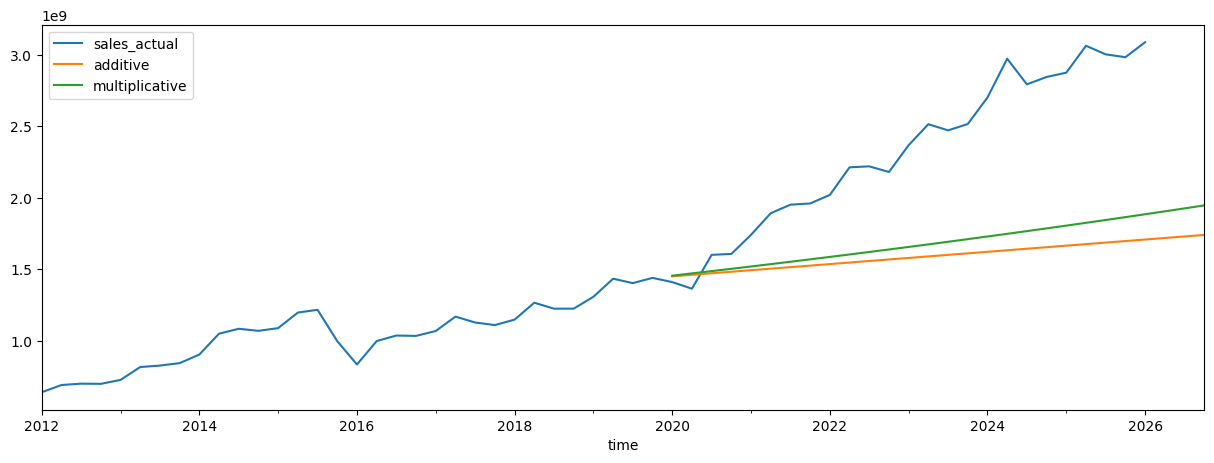

In [4]:
result.plot(figsize=(15, 5));

## Model types

<dl>
<dt>theta</dt>
<dd>The Theta model is a simple forecasting method that combines a linear time trend with a Simple Exponential Smoother.</dd>

<dt>holt_winters</dt>
<dd>Holt's Winters Seasonal Exponential Smoothing is simple exponential smoothing with the addition of trend and seasonality.</dd>

<dt>unobserved</dt>
<dd>Unobserved Components is a classical time series model that breaks the time series into a trend component, a seasonal component, and a cyclical component.</dd>

<dt>sarima</dt>
<dd>SARIMA is a classical time series model. It's a form of regression model with autoregressive terms, meaning that the predictions at one time step depend on the values at previous time steps, and optionally seasonal components.</dd>
   
<dt>prophet</dt>
<dd>The Prophet library uses an additive model, where a time series is modelled as the sum of a trend component and yearly and weekly seasonality components. The model also takes holiday effects into account.</dd>

</dl>

Let's see the forecasts produced by these methods in a practical example:

In [5]:
methods = ["theta", "holt_winters", "unobserved", "sarima"]
signals = [_signal(method, f"va_actual(190).log().forecast('{method}', 'forecast').exp()") for method in methods]

forecasts = client.export_api.export_signals_v2(
    signal=signals,
    resource_name=company.name,
    start_time='2011-01-01',
    end_time='2026-12-31',
)

forecasts.tail(20)

,theta,holt_winters,unobserved,sarima
time,,,,
2026-06-30,"3,343,224,697","3,378,209,449","3,330,341,723","3,299,650,595"
2026-09-30,"3,319,333,698","3,406,293,263","3,342,989,813","3,236,158,059"
2026-12-31,"3,227,891,250","3,366,024,946","3,290,458,917","3,214,807,042"


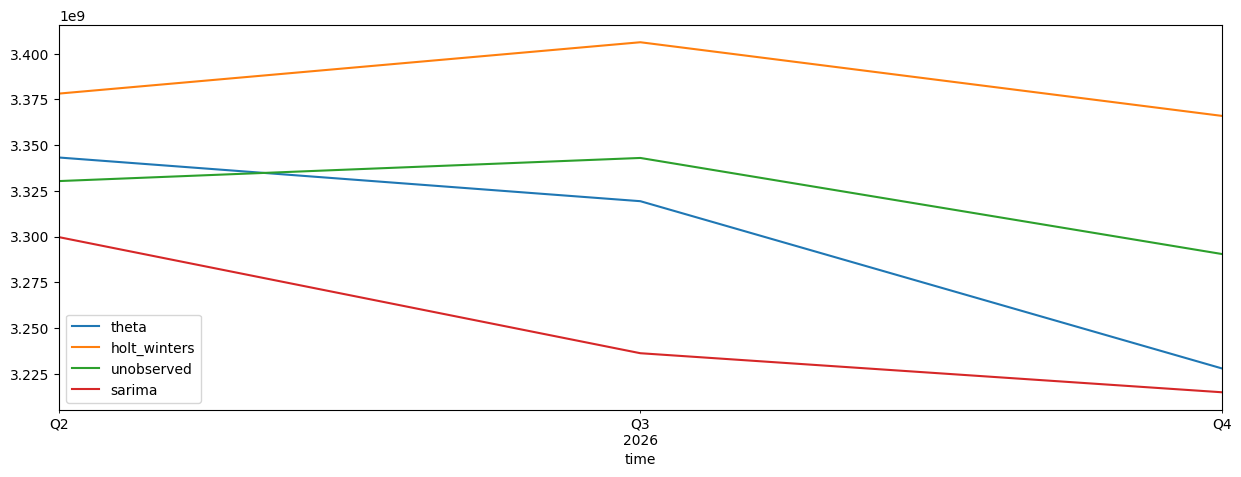

In [6]:
forecasts.plot(figsize=(15, 5));